# Research05: Balanced vs Imbalanced Augmentation Experiment
 
 Research05는 새 Research02 generated windows를 사용해 generative augmentation과 traditional augmentation을 비교한다.
 
 > Research02 masking generation은 structured temporal-block + feature-group masking으로 변경되었다. Research02를 먼저 재실행한 뒤 Research05를 다시 실행해야 한다.
 
 Traditional augmentation은 Lee et al. (2025)의 battery-pack laser welding inspection 논문에서 비교한 `Time warping`, `Magnitude warping`, `Frequency domain`, `Noise injection`, `Comprehensive` 5종을 반영한다.
 
 핵심 질문은 두 가지다.
 
 1. 생성형 시계열 augmentation(GT-GAN, Diffusion 계열)이 전통 augmentation보다 성능이 좋은가?
 2. 성능 변화는 생성 샘플 수 증가 때문인가, 아니면 정상/이상 class ratio balancing 때문인가?
 
 평가는 class imbalance에 민감한 `F1`, `Recall`, `AUPRC`를 중심으로 해석한다.


## 실험 조건

| Condition | 구성 | 의미 |
|---|---:|---|
| Imbalanced | normal 5,000 + real anomaly 247 + generated anomaly 1,000 | 기존처럼 정상 데이터가 많은 조건에서 anomaly augmentation 효과를 확인 |
| Balanced | normal을 anomaly 수에 맞춰 downsample | 정상/이상 비율을 1:1로 맞췄을 때 성능이 좋아지는지 확인 |
| Original only | generated anomaly 0 | augmentation을 쓰지 않은 baseline |

각 augmentation 방법은 anomaly window를 1,000개 생성해서 학습에 추가한다.

In [1]:
from pathlib import Path
import json
import subprocess
import sys

import pandas as pd
from IPython.display import display, Image

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RESULT_DIR = ROOT / "data" / "research05" / "results"
FIG_DIR = ROOT / "data" / "research05" / "figures"
SCRIPT_PATH = ROOT / "tools" / "research05_balanced_aug_experiment.py"
RESEARCH02_SUMMARY_PATH = ROOT / "data" / "research02" / "results" / "research02_generation_summary.json"

with open(RESEARCH02_SUMMARY_PATH, "r", encoding="utf-8") as f:
    research02_summary = json.load(f)

required_keys = {"masking_strategy", "masking_diffusion_denoiser", "temporal_block_ratio", "feature_group_ratio"}
missing = required_keys - set(research02_summary)
if missing:
    raise RuntimeError(f"Research02 generated data is stale. Rerun Research02 first. Missing keys: {sorted(missing)}")

RUN_EXPERIMENTS = True
if RUN_EXPERIMENTS:
    result = subprocess.run(
        [sys.executable, str(SCRIPT_PATH)],
        cwd=ROOT,
        text=True,
        capture_output=True,
    )
    print(result.stdout)
    if result.returncode != 0:
        print(result.stderr)
        raise RuntimeError("Research05 experiment failed")

results = pd.read_csv(RESULT_DIR / "research05_balanced_augmentation_comparison.csv")
best_by_condition = pd.read_csv(RESULT_DIR / "research05_best_by_condition.csv")
best_by_family = pd.read_csv(RESULT_DIR / "research05_best_by_family.csv")

metric_cols = ["precision", "recall", "f1", "f2", "auroc", "auprc"]
for df in [results, best_by_condition, best_by_family]:
    for col in metric_cols + ["normal_to_anomaly_ratio"]:
        if col in df.columns:
            df[col] = df[col].astype(float)

display(research02_summary)
display(results.shape)
display(results.head())


     condition augmentation_family  ... true_normal  true_anomaly
14    balanced         traditional  ...        2785           296
13    balanced         traditional  ...        2785           296
12    balanced         traditional  ...        2785           296
18    balanced          generative  ...        2785           296
17    balanced          generative  ...        2785           296
19    balanced          generative  ...        2785           296
11    balanced         traditional  ...        2785           296
16    balanced          generative  ...        2785           296
15    balanced         traditional  ...        2785           296
10    balanced                none  ...        2785           296
2   imbalanced         traditional  ...        2785           296
3   imbalanced         traditional  ...        2785           296
5   imbalanced         traditional  ...        2785           296
9   imbalanced          generative  ...        2785           296
4   imbala

{'generation_fix': 'Generation follows the paper-style comparison: unmasked GT-GAN and Diffusion sample full windows from noise, while masking-based methods use real anomaly windows with structured masked-value restoration.',
 'masking_strategy': 'Masking-based methods use temporal block masking and feature-group masking instead of element-wise random masking. The observed seed values are preserved, and only masked time/feature regions are restored by the generator.',
 'masking_diffusion_denoiser': 'Masking Diffusion uses a GRU temporal denoiser conditioned on the masked seed window and the binary mask, rather than flattening the window into an MLP denoiser.',
 'n_real': 247,
 'n_generated_per_method': 1000,
 'n_generated_shown_in_tsne': 247,
 'temporal_block_ratio': 0.25,
 'feature_group_ratio': 0.4,
 'residual_scale': 0.35,
 'quality_ranking': ['Masking GT-GAN',
  'Masking Diffusion',
  'Diffusion',
  'GT-GAN']}

(20, 24)

,condition,augmentation_family,method,normal_train_used,real_anomaly_seed_used,generated_anomaly_used,total_anomaly_train_used,normal_to_anomaly_ratio,total_train_rows,threshold,...,precision,recall,f1,f2,auroc,auprc,pred_normal,pred_anomaly,true_normal,true_anomaly
0,balanced,traditional,Frequency domain,1247,247,1000,1247,1.0,2494,0.90,...,0.697595,0.685811,0.691652,0.688136,0.954160,0.729012,2790,291,2785,296
1,balanced,traditional,Noise injection,1247,247,1000,1247,1.0,2494,0.89,...,0.579387,0.702703,0.635115,0.674012,0.954359,0.710963,2722,359,2785,296
2,balanced,traditional,Magnitude warping,1247,247,1000,1247,1.0,2494,0.89,...,0.519894,0.662162,0.582467,0.627803,0.950000,0.711443,2704,377,2785,296
3,balanced,generative,Diffusion,1247,247,1000,1247,1.0,2494,0.88,...,0.505025,0.679054,0.579251,0.635272,0.941996,0.668603,2683,398,2785,296
4,balanced,generative,Masking GT-GAN,1247,247,1000,1247,1.0,2494,0.93,...,0.469108,0.692568,0.559345,0.632326,0.926958,0.670693,2644,437,2785,296


## 전체 성능 순위

아래 표는 모든 조건과 augmentation 방법을 `F1` 기준으로 정렬한 결과다. 어떤 조건과 방법이 상위권인지 재실행 결과를 기준으로 확인한다.

In [2]:
ranking = (
    results
    .sort_values('f1', ascending=False)
    [[
        'condition', 'augmentation_family', 'method',
        'normal_train_used', 'total_anomaly_train_used', 'normal_to_anomaly_ratio',
        'precision', 'recall', 'f1', 'auroc', 'auprc'
    ]]
    .reset_index(drop=True)
)

ranking.style.format({
    'normal_to_anomaly_ratio': '{:.2f}',
    'precision': '{:.3f}',
    'recall': '{:.3f}',
    'f1': '{:.3f}',
    'auroc': '{:.3f}',
    'auprc': '{:.3f}',
}).background_gradient(subset=['f1', 'recall', 'auprc'], cmap='YlGn')

,condition,augmentation_family,method,normal_train_used,total_anomaly_train_used,normal_to_anomaly_ratio,precision,recall,f1,auroc,auprc
0,imbalanced,traditional,Magnitude warping,5000,1247,4.01,0.964,0.814,0.883,0.994,0.959
1,imbalanced,traditional,Noise injection,5000,1247,4.01,0.954,0.764,0.848,0.992,0.941
2,imbalanced,traditional,Comprehensive,5000,1247,4.01,0.900,0.791,0.842,0.991,0.934
3,imbalanced,generative,Masking Diffusion,5000,1247,4.01,0.868,0.780,0.822,0.985,0.911
4,imbalanced,traditional,Frequency domain,5000,1247,4.01,0.843,0.801,0.821,0.987,0.897
5,imbalanced,generative,Masking GT-GAN,5000,1247,4.01,0.897,0.615,0.729,0.966,0.832
6,imbalanced,generative,GT-GAN,5000,1247,4.01,0.935,0.588,0.722,0.985,0.886
7,imbalanced,none,Original only,5000,247,20.24,0.923,0.564,0.700,0.961,0.810
8,balanced,traditional,Frequency domain,1247,1247,1.00,0.698,0.686,0.692,0.954,0.729
9,imbalanced,generative,Diffusion,5000,1247,4.01,0.792,0.591,0.677,0.978,0.835


## 조건별 최고 성능
 
 아래 코드 셀의 `condition_summary`가 재실행된 Research05 결과에서 condition별 최고 성능을 계산한다. 이전 실행의 method 이름이나 수치를 고정해서 사용하지 않는다.


In [ ]:
condition_summary = (
    best_by_condition
    .sort_values('f1', ascending=False)
    [[
        'condition', 'augmentation_family', 'method',
        'normal_train_used', 'total_anomaly_train_used', 'normal_to_anomaly_ratio',
        'precision', 'recall', 'f1', 'auroc', 'auprc'
    ]]
)

condition_summary.style.format({
    'normal_to_anomaly_ratio': '{:.2f}',
    'precision': '{:.3f}',
    'recall': '{:.3f}',
    'f1': '{:.3f}',
    'auroc': '{:.3f}',
    'auprc': '{:.3f}',
}).hide(axis='index')

condition,augmentation_family,method,normal_train_used,total_anomaly_train_used,normal_to_anomaly_ratio,precision,recall,f1,auroc,auprc
imbalanced,traditional,Magnitude warping,5000,1247,4.01,0.964,0.814,0.883,0.994,0.959
balanced,traditional,Frequency domain,1247,1247,1.00,0.698,0.686,0.692,0.954,0.729


## Augmentation family별 최고 성능 비교
 
 아래 표는 재실행된 결과에서 condition과 augmentation family 조합별 best method를 계산한다. structured masking 이후 `Masking GT-GAN`/`Masking Diffusion` 성능은 여기서 새로 확인한다.


In [4]:
family_summary = (
    best_by_family
    .sort_values(['condition', 'f1'], ascending=[True, False])
    [[
        'condition', 'augmentation_family', 'method',
        'precision', 'recall', 'f1', 'auroc', 'auprc'
    ]]
)

family_summary.style.format({
    'precision': '{:.3f}',
    'recall': '{:.3f}',
    'f1': '{:.3f}',
    'auroc': '{:.3f}',
    'auprc': '{:.3f}',
}).background_gradient(subset=['f1', 'recall', 'auprc'], cmap='Blues').hide(axis='index')

condition,augmentation_family,method,precision,recall,f1,auroc,auprc
balanced,traditional,Frequency domain,0.698,0.686,0.692,0.954,0.729
balanced,generative,Diffusion,0.505,0.679,0.579,0.942,0.669
balanced,none,Original only,0.239,0.794,0.368,0.838,0.351
imbalanced,traditional,Magnitude warping,0.964,0.814,0.883,0.994,0.959
imbalanced,generative,Masking Diffusion,0.868,0.780,0.822,0.985,0.911
imbalanced,none,Original only,0.923,0.564,0.700,0.961,0.810


## Augmentation family별 전체 결과

아래 표는 대표값이 아니라 모든 method를 condition과 augmentation family별로 묶어서 보여준다. 비율 열은 학습에 사용한 정상/이상 데이터 개수를 표시하고, 각 그룹 안에서는 F1이 높은 순서로 정렬했다.

In [5]:
family_full_results = (
    results
    .sort_values(['condition', 'augmentation_family', 'f1'], ascending=[True, True, False])
    [[
        'condition', 'augmentation_family', 'method',
        'normal_train_used', 'real_anomaly_seed_used', 'generated_anomaly_used',
        'total_anomaly_train_used', 'total_train_rows',
        'precision', 'recall', 'f1', 'auroc', 'auprc'
    ]]
    .reset_index(drop=True)
)

family_full_results.style.format({
    'normal_train_used': '{:,.0f}',
    'real_anomaly_seed_used': '{:,.0f}',
    'generated_anomaly_used': '{:,.0f}',
    'total_anomaly_train_used': '{:,.0f}',
    'total_train_rows': '{:,.0f}',
    'precision': '{:.3f}',
    'recall': '{:.3f}',
    'f1': '{:.3f}',
    'auroc': '{:.3f}',
    'auprc': '{:.3f}',
}).background_gradient(subset=['precision', 'recall', 'f1', 'auroc', 'auprc'], cmap='YlGn').hide(axis='index')

condition,augmentation_family,method,normal_train_used,real_anomaly_seed_used,generated_anomaly_used,total_anomaly_train_used,total_train_rows,precision,recall,f1,auroc,auprc
balanced,generative,Diffusion,"1,247",247,"1,000","1,247","2,494",0.505,0.679,0.579,0.942,0.669
balanced,generative,Masking GT-GAN,"1,247",247,"1,000","1,247","2,494",0.469,0.693,0.559,0.927,0.671
balanced,generative,Masking Diffusion,"1,247",247,"1,000","1,247","2,494",0.507,0.611,0.554,0.922,0.643
balanced,generative,GT-GAN,"1,247",247,"1,000","1,247","2,494",0.537,0.514,0.525,0.916,0.589
balanced,none,Original only,247,247,0,247,494,0.239,0.794,0.368,0.838,0.351
balanced,traditional,Frequency domain,"1,247",247,"1,000","1,247","2,494",0.698,0.686,0.692,0.954,0.729
balanced,traditional,Noise injection,"1,247",247,"1,000","1,247","2,494",0.579,0.703,0.635,0.954,0.711
balanced,traditional,Magnitude warping,"1,247",247,"1,000","1,247","2,494",0.520,0.662,0.582,0.950,0.711
balanced,traditional,Time warping,"1,247",247,"1,000","1,247","2,494",0.461,0.618,0.528,0.919,0.513
balanced,traditional,Comprehensive,"1,247",247,"1,000","1,247","2,494",0.366,0.831,0.508,0.922,0.585


## 그래프 1: Balanced vs Imbalanced 성능 비교

같은 augmentation이라도 balanced 조건보다 imbalanced 조건에서 F1과 AUPRC가 더 높게 나오는 경향이 뚜렷하다.

![Balanced vs Imbalanced Scores](../data/research05/figures/balanced_vs_imbalanced_scores.png)

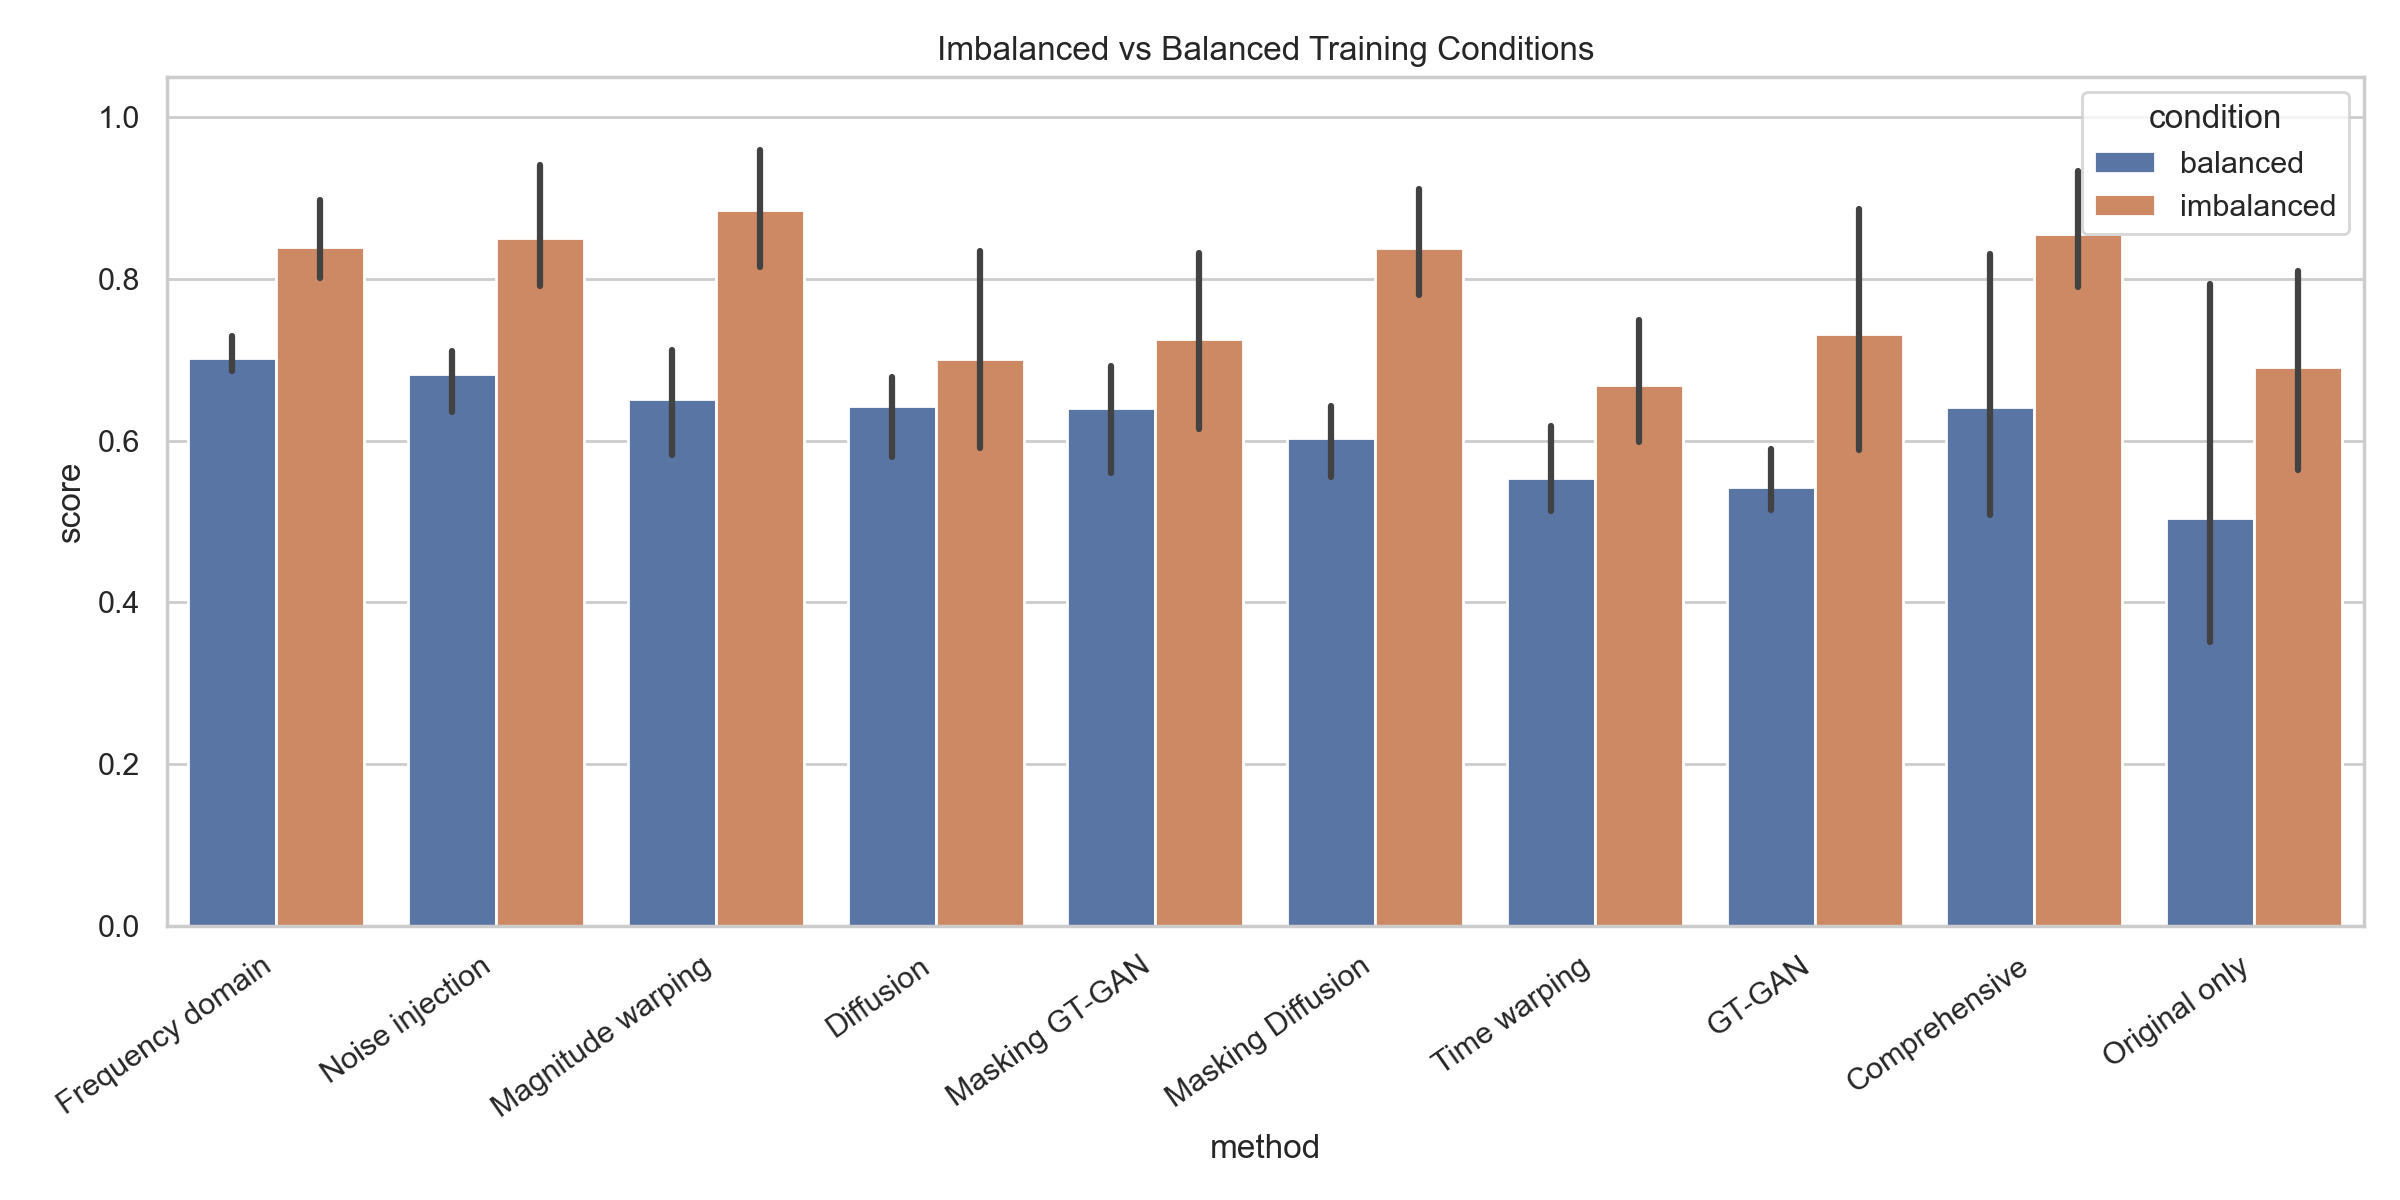

In [6]:
display(Image(filename=str(FIG_DIR / 'balanced_vs_imbalanced_scores.png')))

## 그래프 2: Class ratio와 F1 관계

1:1 balancing 자체가 성능 향상의 원인인지, 아니면 정상 데이터를 많이 제거하면서 성능이 낮아지는지 그래프에서 확인한다.

![F1 by Class Ratio](../data/research05/figures/f1_by_class_ratio.png)

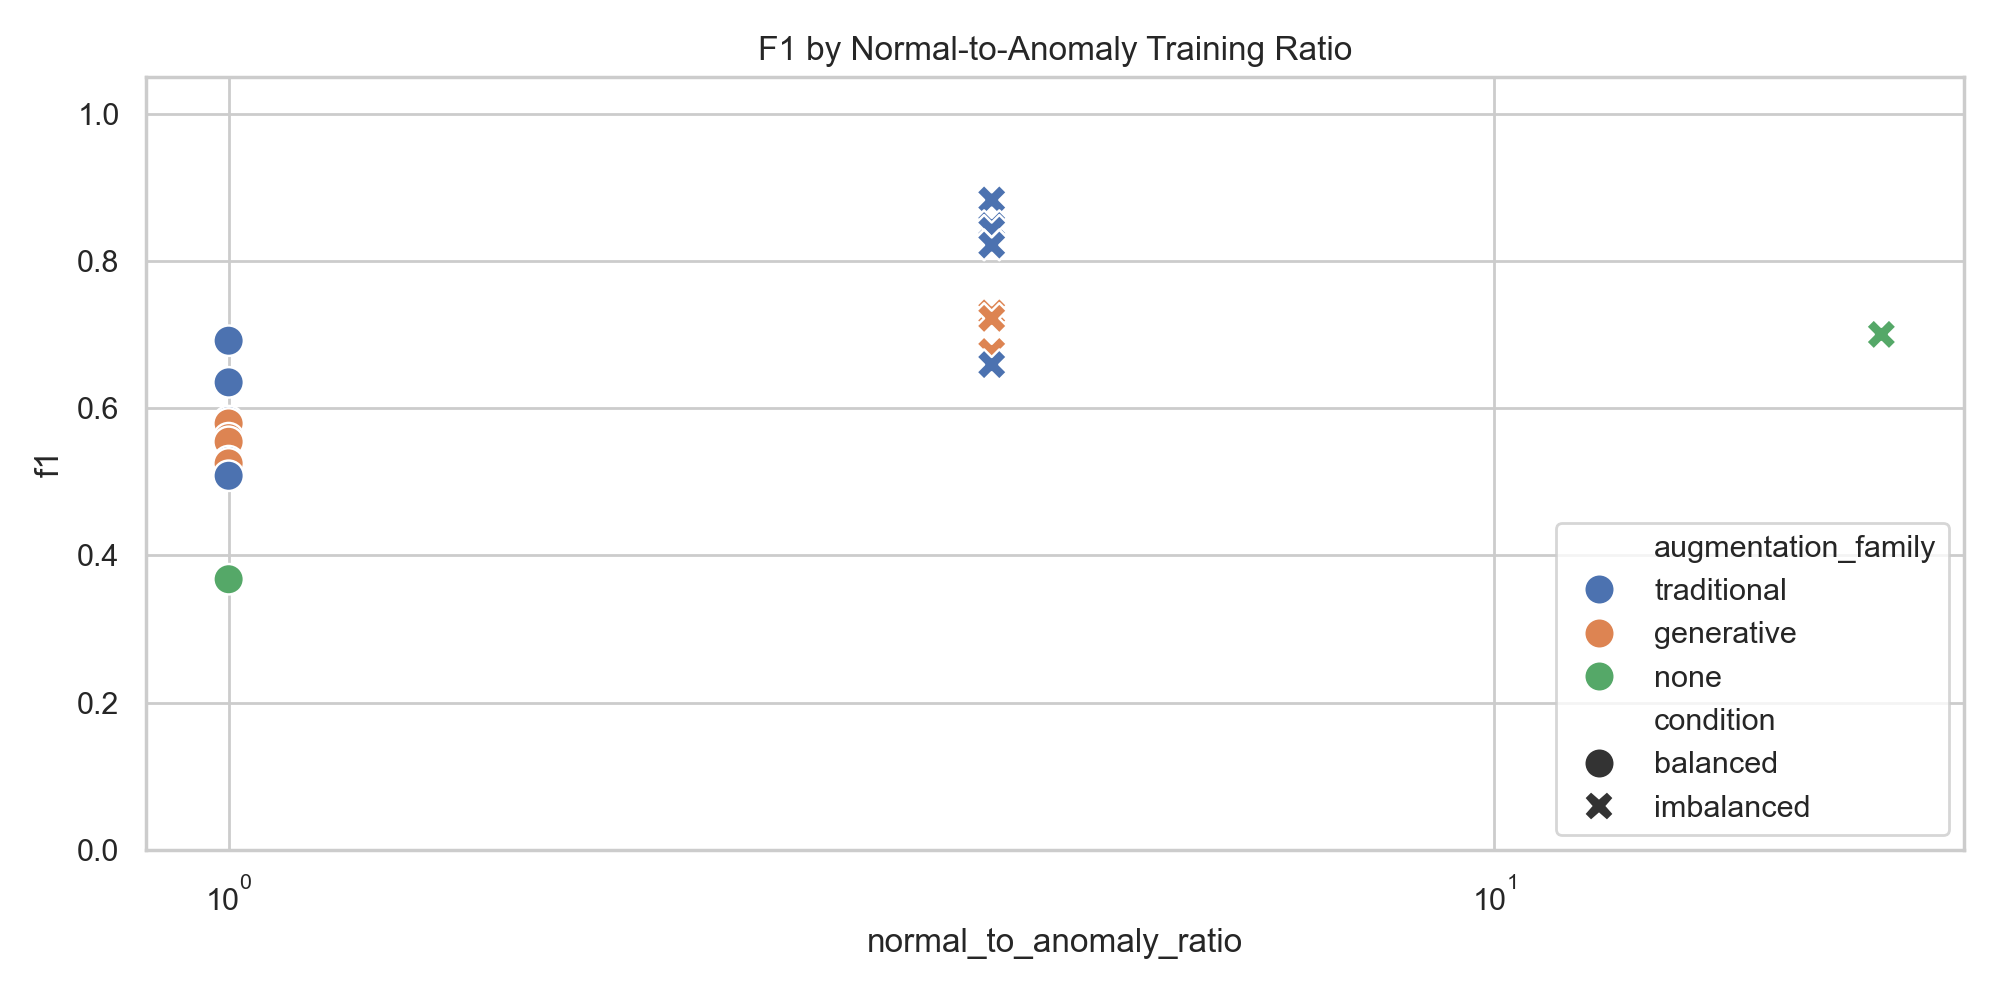

'[Training'��(��) ���� �Ǵ� �ܺ� ����, ������ �� �ִ� ���α׷�, �Ǵ�
��ġ ������ �ƴմϴ�.


In [7]:
display(Image(filename=str(FIG_DIR / 'f1_by_class_ratio.png')))
## 그래프 3: 학습 데이터 개수와 F1/Recall 관계

#아래 그래프는 class ratio 대신 실제 학습 데이터 개수를 기준으로 F1과 Recall이 어떻게 움직이는지 분리해서 보여준다. 왼쪽 패널은 F1, 오른쪽 패널은 Recall이다. x축에는 정상 데이터 수(N), 전체 이상 데이터 수(A), 전체 학습 row 수를 표시했다. 각 점은 하나의 method이고, 얇은 회색 선은 같은 method의 balanced/imbalanced/original 조건을 연결한다. 검은 마름모는 해당 학습 구성의 평균 score를 나타낸다. 원형은 balanced 조건, 사각형은 imbalanced 조건을 나타낸다.

![Training Counts vs F1 and Recall](../data/research05/figures/training_counts_f1_recall_relationship.png)

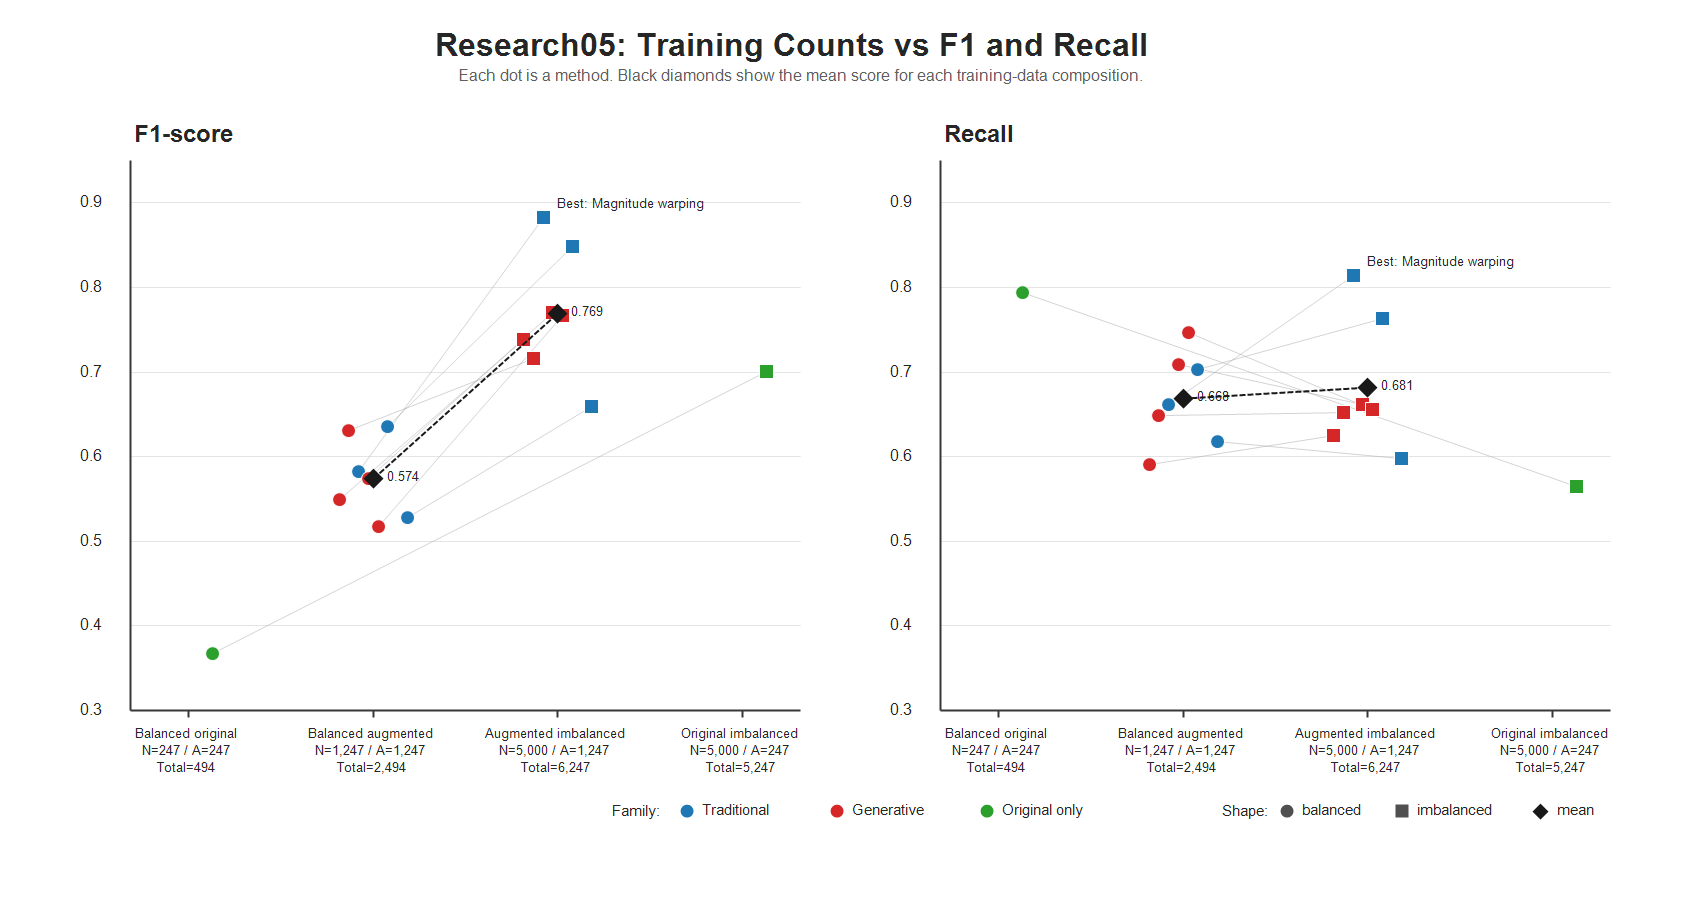

In [8]:
display(Image(filename=str(FIG_DIR / 'training_counts_f1_recall_relationship.png')))

## 핵심 결과 정리
 
 이 섹션은 Research05를 재실행한 뒤 아래 항목을 중심으로 다시 작성한다.
 
 - 전체 best method가 generative인지 traditional인지
 - structured masking 기반 `Masking Diffusion`/`Masking GT-GAN`이 plain Diffusion/GT-GAN보다 나아졌는지
 - imbalanced 조건과 balanced 조건 중 어느 쪽에서 F1, Recall, AUPRC가 높은지
 - 성능 향상이 class ratio balancing 때문인지, anomaly sample 추가 때문인지


## 최종 결론
 
 최종 결론은 재실행된 `research05_summary.json`, `research05_best_by_condition.csv`, `research05_best_by_family.csv` 기준으로 작성한다. 이전 Research02 element-wise masking 결과에서 나온 수치는 사용하지 않는다.
 
 보고서 문장은 다음 형식으로 정리한다.
 
 > After replacing element-wise random masking with temporal block and feature-group masking, we re-evaluated generative augmentation under balanced and imbalanced training conditions. The final conclusion should be based on the updated best method, F1-score, recall, and AUPRC from the rerun Research05 results.


## 저장된 결과 파일

- `data/research05/results/research05_balanced_augmentation_comparison.csv`: 전체 비교 결과
- `data/research05/results/research05_best_by_condition.csv`: balanced/imbalanced 조건별 최고 성능
- `data/research05/results/research05_best_by_family.csv`: augmentation family별 최고 성능
- `data/research05/results/research05_summary.json`: 실험 질문과 요약 결과
- `data/research05/figures/balanced_vs_imbalanced_scores.png`: 조건별 metric 비교 그래프
- `data/research05/figures/f1_by_class_ratio.png`: class ratio and F1 figure
